# gpt-oss P2 — grid loudness per layer

Which layer is most **grid**-loaded, over every reasoning token of the train 2,880. On gpt-oss
the probe layer is 15 by convention, so this describes where 15 sits rather than choosing
it, exactly as the gpt-oss direction profile does.

Input is what `wrappers/gptoss_analysis/grid/1_loudest_layer/join_loudness_profile.sh` writes: one
row per reasoning token, one `L{layer}` column per layer, each cell `log P(any grid word)` at
that (token, layer), over the pruned 642-token grid vocabulary.

An **empty** cell means the lens did not cover that layer (the jlens outside its fitted
range) — not "no mass here". It becomes `NaN` and is skipped by the mean.

Most grid mass is AXIS (row/column words), so a peak here is
largely a coordinate-bookkeeping peak.

In [1]:
# 1. imports and load the joined tables
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

OUT_DIR = Path("/workspace/loudness_evaluation/gptoss_p2_grid_layer_profile")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# keep_default_na=False: decoded tokens include the literal string "NA" and empty
# strings, which pandas would otherwise turn into missing values.
jlens = pd.read_csv(OUT_DIR / "jlens_tokens.csv", keep_default_na=False, low_memory=False)
logitlens = pd.read_csv(OUT_DIR / "logitlens_tokens.csv", keep_default_na=False, low_memory=False)

print(f"jlens:     {len(jlens):,} token rows, {jlens.trajectory.nunique():,} trajectories")
print(f"logitlens: {len(logitlens):,} token rows, {logitlens.trajectory.nunique():,} trajectories")
jlens.head()

jlens:     776,191 token rows, 2,880 trajectories
logitlens: 776,191 token rows, 2,880 trajectories


,trajectory,size,complexity,run,step,reasoning_pos,abs_pos,token,agent_action,L7,...,L14,L15,L16,L17,L18,L19,L20,L21,L22,L23
0,together_ai_openai_gpt-oss-20b_size11_comp0.0_11,11,0.0,11,0,0,717,Goal,LEFT,-2.798352,...,-2.215512,-1.719292,-0.979439,-0.945564,-0.702997,-0.963161,-1.396130,-3.461103,-1.678445,-1.474520
1,together_ai_openai_gpt-oss-20b_size11_comp0.0_11,11,0.0,11,0,1,718,Ġat,LEFT,-3.147074,...,-2.273046,-1.728167,-0.851726,-0.577149,-0.091576,-0.030643,-0.138470,-0.537907,-0.492796,-2.973900
2,together_ai_openai_gpt-oss-20b_size11_comp0.0_11,11,0.0,11,0,2,719,Ġ(,LEFT,-4.081313,...,-4.966258,-4.516258,-3.865309,-5.569096,-3.106726,-2.188990,-0.746752,-5.122919,-5.750734,-8.611967
3,together_ai_openai_gpt-oss-20b_size11_comp0.0_11,11,0.0,11,0,3,720,1,LEFT,-4.315555,...,-4.328140,-3.904974,-4.216645,-3.026335,-1.299063,-3.302014,-2.735434,-3.334023,-5.817564,-12.493114
4,together_ai_openai_gpt-oss-20b_size11_comp0.0_11,11,0.0,11,0,4,721,",",LEFT,-4.156233,...,-2.810433,-2.826654,-2.054424,-2.554012,-2.516432,-4.905038,-9.332215,-14.224438,-14.957800,-16.777100


In [2]:
# 2. aggregate at row level — every token is one observation
def layer_columns(df):
    """The L{layer} columns, in layer order."""
    cols = [c for c in df.columns if c.startswith("L") and c[1:].isdigit()]
    return sorted(cols, key=lambda c: int(c[1:]))


def loudness_matrix(df):
    """Just the layer columns, numeric. Empty cells (layer not covered) become NaN."""
    cols = layer_columns(df)
    return df[cols].apply(pd.to_numeric, errors="coerce")


jlens_mass = loudness_matrix(jlens)
logitlens_mass = loudness_matrix(logitlens)

print("layers:", [int(c[1:]) for c in layer_columns(jlens)])
print(f"jlens rows: {len(jlens_mass):,}   logitlens rows: {len(logitlens_mass):,}")

layers: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
jlens rows: 776,191   logitlens rows: 776,191


In [3]:
# 3. mean grid loudness per layer
def mean_per_layer(mass):
    """{layer: mean loudness}, as a Series indexed by integer layer."""
    means = mass.mean()  # skips NaN
    means.index = [int(c[1:]) for c in means.index]
    return means.sort_index()


jlens_per_layer = mean_per_layer(jlens_mass)
logitlens_per_layer = mean_per_layer(logitlens_mass)

print(f"jlens argmax layer:     {jlens_per_layer.idxmax()}  ({jlens_per_layer.max():.4f})")
print(f"logitlens argmax layer: {logitlens_per_layer.idxmax()}  ({logitlens_per_layer.max():.4f})")
pd.DataFrame({"jlens": jlens_per_layer, "logitlens": logitlens_per_layer})

jlens argmax layer:     9  (-3.8973)
logitlens argmax layer: 13  (-3.7799)


,jlens,logitlens
7,-4.063458,-5.084519
8,-3.958730,-4.851541
9,-3.897348,-4.347335
10,-4.043741,-4.223292
11,-3.947411,-3.912197
12,-3.998288,-3.942161
13,-4.005251,-3.779902
14,-4.135022,-4.050194
15,-4.285937,-4.458429
16,-4.136136,-6.002873


saved /workspace/loudness_evaluation/gptoss_p2_grid_layer_profile/figures/jlens_loudness_per_layer.png


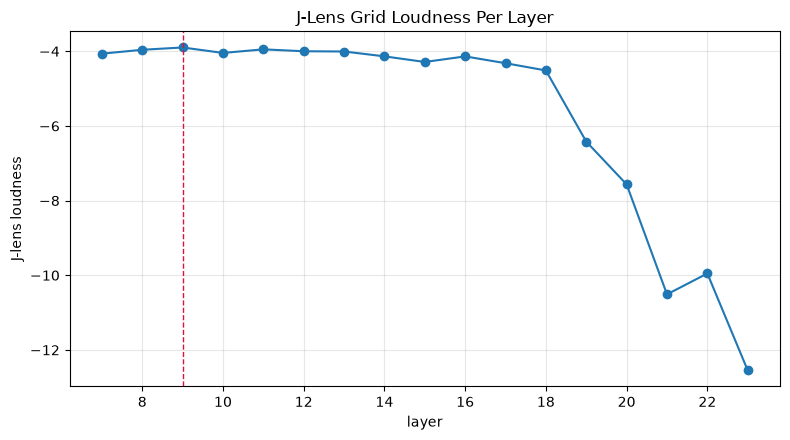

In [4]:
# 4. J-Lens Grid Loudness Per Layer
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(jlens_per_layer.index, jlens_per_layer.values, marker="o")
ax.axvline(jlens_per_layer.idxmax(), color="crimson", linestyle="--", linewidth=1)
ax.set_title("J-Lens Grid Loudness Per Layer")
ax.set_xlabel("layer")
ax.set_ylabel("J-lens loudness")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "jlens_loudness_per_layer.png", dpi=160, bbox_inches="tight")
print("saved", FIG_DIR / "jlens_loudness_per_layer.png")
plt.show()

saved /workspace/loudness_evaluation/gptoss_p2_grid_layer_profile/figures/logitlens_loudness_per_layer.png


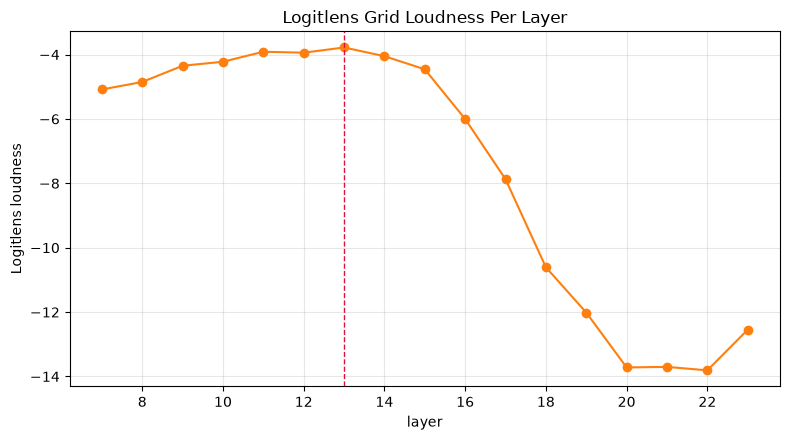

In [5]:
# 5. Logitlens Grid Loudness Per Layer
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(logitlens_per_layer.index, logitlens_per_layer.values, marker="o", color="tab:orange")
ax.axvline(logitlens_per_layer.idxmax(), color="crimson", linestyle="--", linewidth=1)
ax.set_title("Logitlens Grid Loudness Per Layer")
ax.set_xlabel("layer")
ax.set_ylabel("Logitlens loudness")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "logitlens_loudness_per_layer.png", dpi=160, bbox_inches="tight")
print("saved", FIG_DIR / "logitlens_loudness_per_layer.png")
plt.show()